In [62]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#froms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.metrics import silhouette_score

In [63]:
# globales
df = pd.read_csv("../../data/dataset_for_clustering.csv", encoding="ISO-8859-1", low_memory=False)
print(f'\n DF limpio:')
print(df.info())


 DF limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336697 entries, 0 to 336696
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    336697 non-null  object 
 1   StockCode    336697 non-null  object 
 2   Description  336697 non-null  object 
 3   Quantity     336697 non-null  int64  
 4   InvoiceDate  336697 non-null  object 
 5   UnitPrice    336697 non-null  float64
 6   CustomerID   336697 non-null  float64
 7   Country      336697 non-null  object 
 8   TotalSales   336697 non-null  float64
 9   Year         336697 non-null  int64  
 10  Month        336697 non-null  int64  
 11  Day          336697 non-null  int64  
 12  DayOfWeek    336697 non-null  int64  
 13  Quarter      336697 non-null  int64  
 14  Season       336697 non-null  object 
dtypes: float64(3), int64(6), object(6)
memory usage: 38.5+ MB
None


In [64]:
mask = df['Country'] == "United Kingdom"
df = df[mask]

In [65]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,Day,DayOfWeek,Quarter,Season
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,2,4,Winter
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,2,4,Winter
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter


In [66]:
#config
df_grouped = df.groupby(['InvoiceNo', 'CustomerID'])['TotalSales'].sum().reset_index()
df_grouped

df_to_use = df_grouped.groupby(['CustomerID']).agg({
  "TotalSales": "sum",
  "InvoiceNo": "count"
}).reset_index()

df_to_use

,CustomerID,TotalSales,InvoiceNo
0,12747.0,1959.01,11
1,12748.0,24601.48,214
2,12749.0,3615.00,8
3,12820.0,942.34,4
4,12821.0,92.72,1
...,...,...,...
3826,18280.0,180.60,1
3827,18281.0,80.82,1
3828,18282.0,176.60,3
3829,18283.0,2045.53,16


In [67]:
df_to_use['mediaTicket'] = df_to_use['TotalSales']/df_to_use['InvoiceNo']

In [68]:
df_to_use = df_to_use.sort_values('InvoiceNo')
df_to_use

,CustomerID,TotalSales,InvoiceNo,mediaTicket
15,12834.0,312.38,1,312.380000
14,12833.0,417.38,1,417.380000
12,12831.0,215.05,1,215.050000
6,12824.0,397.12,1,397.120000
4,12821.0,92.72,1,92.720000
...,...,...,...,...
183,13089.0,32484.99,100,324.849900
1731,15311.0,13532.11,113,119.753186
1239,14606.0,10969.59,127,86.374724
3518,17841.0,35683.76,169,211.146509


In [69]:
camposUsar = df_to_use[['TotalSales', 'InvoiceNo', 'mediaTicket']]

# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_to_use["Cluster"] = kmeans.fit_predict(camposUsar) # Añadimos al df la prediccion, nº cluster de cada punto

# Evaluar la inercia del modelo
kmeans.inertia_

1793369227.2967582

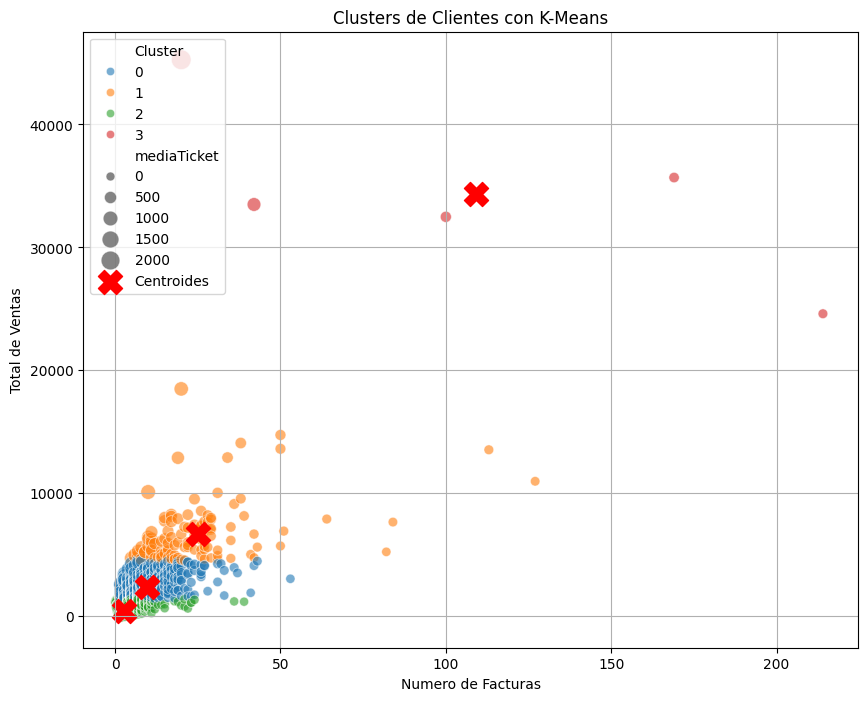

In [70]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='InvoiceNo', 
    y='TotalSales', 
    hue='Cluster',
    size='mediaTicket',
    sizes=(20, 200),
    alpha=0.6,
    palette='tab10',
    data=df_to_use
)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], 
            s=300, c='red', marker='X', label='Centroides')

plt.ylabel("Total de Ventas")
plt.xlabel("Numero de Facturas")
plt.title("Clusters de Clientes con K-Means")
plt.legend(loc='upper left')
plt.grid()
plt.show()

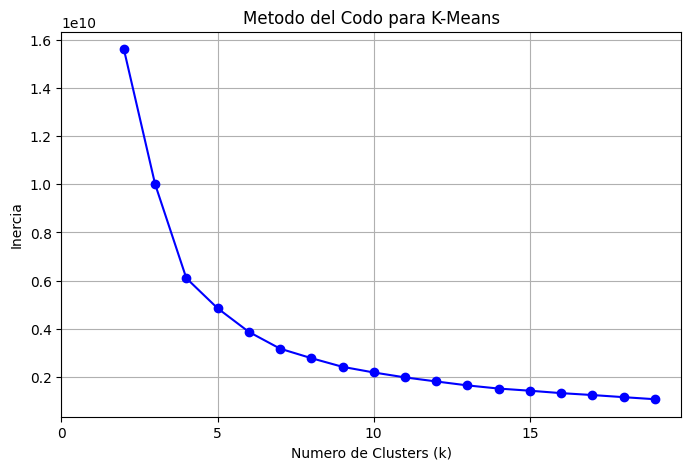

In [22]:
# Rango de valores de k que quieres probar
k_values = range(2, 20)  # Puedes ajustarlo segun lo necesites
inertia_values = []

# Calcular inercia para cada valor de k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # definicion del modelo
    kmeans.fit(df_to_use) # entrenamiento
    inertia_values.append(kmeans.inertia_) # guardamos la inercia

# Grafica
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo del Codo para K-Means')
plt.xticks(np.arange(0, 20, step=5))  # Ajusta los ticks para mejor visualización
plt.grid()
plt.show()

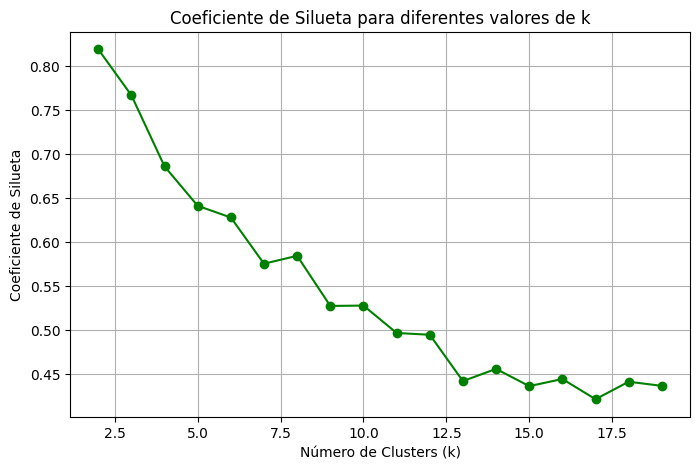

Best k=2, silhouette value= 0.8185


In [23]:

best_k = None
best_silhouette = -1
silhouette_scores = []

for k in range(2, 20):  # Evaluamos entre 2 y 20 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(camposUsar) # Entrenamos cada modelo
    silhouette = silhouette_score(camposUsar, labels) # calcula el indice de silueta
    silhouette_scores.append(silhouette)
    
    if silhouette > best_silhouette: # Cuanto mayor indice de silueta mejor
        best_silhouette = silhouette
        best_k = k

# Grafica
plt.figure(figsize=(8, 5))
plt.plot(range(2, 20), silhouette_scores, marker='o', linestyle='-', color='g')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Coeficiente de Silueta para diferentes valores de k')
plt.grid()
plt.show()

print(f"Best k={best_k}, silhouette value= {best_silhouette:.4f}")

## Clientes por cada cluster. Gráficos

### Cluster 2 - Clientes con valor bajo

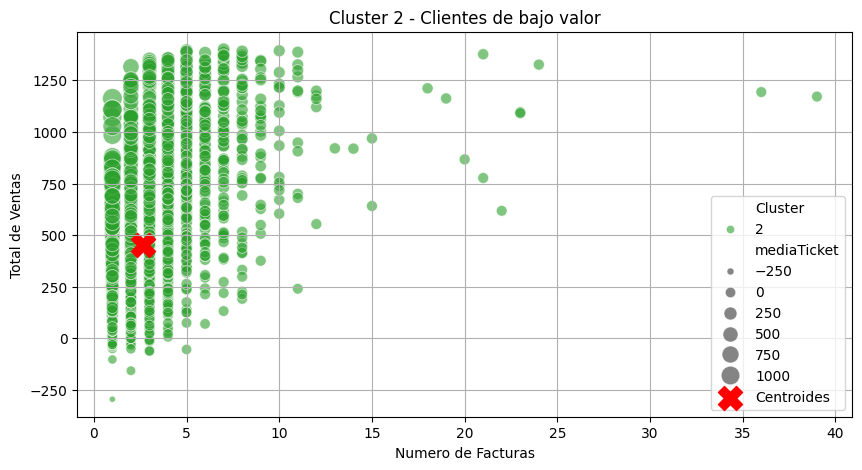

In [83]:
df_to_represent = df_to_use[df_to_use['Cluster'] == 2]
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x='InvoiceNo', 
    y='TotalSales', 
    hue='Cluster',
    size='mediaTicket',
    sizes=(20, 200),
    alpha=0.6,
    palette={ 2: '#2ca02c' },
    data=df_to_represent
)
plt.scatter(kmeans.cluster_centers_[2, 1], kmeans.cluster_centers_[2, 0], s=300, c='red', marker='X', label='Centroides')
plt.ylabel("Total de Ventas")
plt.xlabel("Numero de Facturas")
plt.title("Cluster 2 - Clientes de bajo valor")
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [120]:
df_cluster_2 = df_to_use[df_to_use['Cluster'] == 2]

grouped_cluster_2 = df_cluster_2.groupby('CustomerID').agg({
  "TotalSales": "sum",
  "InvoiceNo": "sum"
})

df_metrics = pd.DataFrame({
  'Metrica': [
    'Número de clientes',
    'Promedio de número de facturas por cliente',
    'Promedio de ventas totales',
    'Número mínimo de facturas',
    'Número máximo de facturas',
    'Ventas totales mínimas',
    'Ventas totales máximas'
  ],
  'Valor': [
    int(grouped_cluster_2.shape[0]),
    round(grouped_cluster_2['InvoiceNo'].mean(), 0).astype(int),
    round(grouped_cluster_2['TotalSales'].mean(), 0).astype(int),
    int(grouped_cluster_2['InvoiceNo'].min()),
    int(grouped_cluster_2['InvoiceNo'].max()),
    int(grouped_cluster_2['TotalSales'].min()),
    int(grouped_cluster_2['TotalSales'].max())
  ]
})

df_metrics

,Metrica,Valor
0,Número de clientes,3018
1,Promedio de número de facturas por cliente,3
2,Promedio de ventas totales,450
3,Número mínimo de facturas,1
4,Número máximo de facturas,39
5,Ventas totales mínimas,-295
6,Ventas totales máximas,1400


### Cluster 0 - Clientes con valor medio

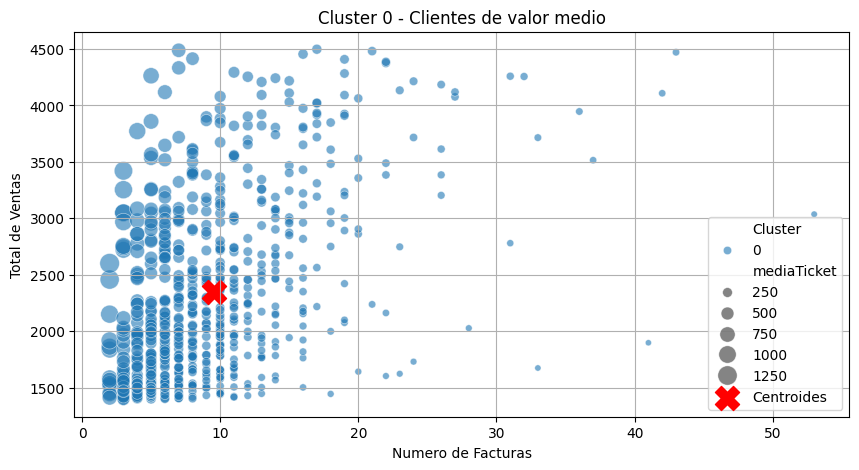

In [ ]:
df_to_represent = df_to_use[df_to_use['Cluster'] == 0]
plt.figure(figsize=(10, 5))
sns.scatterplot(
  x='InvoiceNo', 
  y='TotalSales', 
  hue='Cluster',
  size='mediaTicket',
  sizes=(20, 200),
  alpha=0.6,
  palette={ 0: "#1f77b4" },
  data=df_to_represent
)
plt.scatter(kmeans.cluster_centers_[0, 1], kmeans.cluster_centers_[0, 0], s=300, c='red', marker='X', label='Centroides')
plt.ylabel("Total de Ventas")
plt.xlabel("Numero de Facturas")
plt.title("Cluster 0 - Clientes de valor medio")
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [122]:
df_cluster_0 = df_to_use[df_to_use['Cluster'] == 0]

grouped_cluster_0 = df_cluster_0.groupby('CustomerID').agg({
  "TotalSales": "sum",
  "InvoiceNo": "sum"
})

df_metrics = pd.DataFrame({
  'Metrica': [
    'Número de clientes',
    'Promedio de número de facturas por cliente',
    'Promedio de ventas totales',
    'Número mínimo de facturas',
    'Número máximo de facturas',
    'Ventas totales mínimas',
    'Ventas totales máximas'
  ],
  'Valor': [
    int(grouped_cluster_0.shape[0]),
    round(grouped_cluster_0['InvoiceNo'].mean(), 0).astype(int),
    round(grouped_cluster_0['TotalSales'].mean(), 0).astype(int),
    int(grouped_cluster_0['InvoiceNo'].min()),
    int(grouped_cluster_0['InvoiceNo'].max()),
    int(grouped_cluster_0['TotalSales'].min()),
    int(grouped_cluster_0['TotalSales'].max())
  ]
})

df_metrics

,Metrica,Valor
0,Número de clientes,693
1,Promedio de número de facturas por cliente,10
2,Promedio de ventas totales,2346
3,Número mínimo de facturas,2
4,Número máximo de facturas,53
5,Ventas totales mínimas,1396
6,Ventas totales máximas,4498


### Cluster 1 - Clientes de alto valor

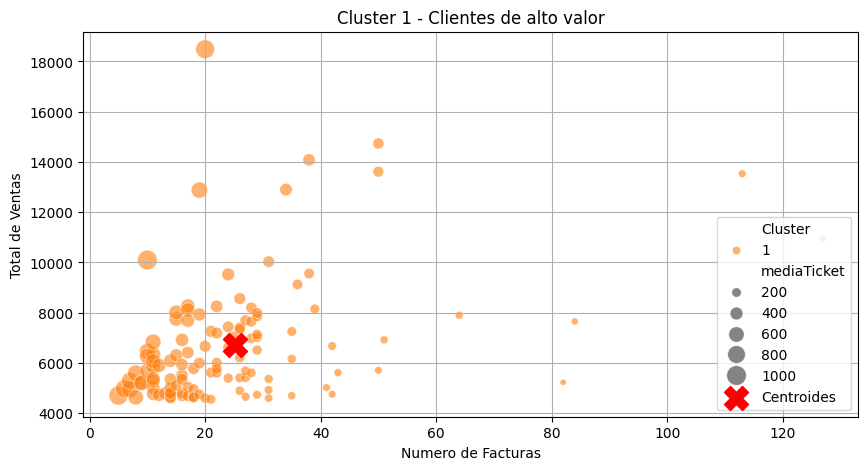

In [85]:
df_to_represent = df_to_use[df_to_use['Cluster'] == 1]
plt.figure(figsize=(10, 5))
sns.scatterplot(
  x='InvoiceNo', 
  y='TotalSales', 
  hue='Cluster',
  size='mediaTicket',
  sizes=(20, 200),
  alpha=0.6,
  palette={ 1: "#ff7f0e" },
  data=df_to_represent
)
plt.scatter(kmeans.cluster_centers_[1, 1], kmeans.cluster_centers_[1, 0], s=300, c='red', marker='X', label='Centroides')
plt.ylabel("Total de Ventas")
plt.xlabel("Numero de Facturas")
plt.title("Cluster 1 - Clientes de alto valor")
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [124]:
df_cluster_1 = df_to_use[df_to_use['Cluster'] == 1]

grouped_cluster_1 = df_cluster_1.groupby('CustomerID').agg({
  "TotalSales": "sum",
  "InvoiceNo": "sum"
})

df_metrics = pd.DataFrame({
  'Metrica': [
    'Número de clientes',
    'Promedio de número de facturas por cliente',
    'Promedio de ventas totales',
    'Número mínimo de facturas',
    'Número máximo de facturas',
    'Ventas totales mínimas',
    'Ventas totales máximas'
  ],
  'Valor': [
    int(grouped_cluster_1.shape[0]),
    round(grouped_cluster_1['InvoiceNo'].mean(), 0).astype(int),
    round(grouped_cluster_1['TotalSales'].mean(), 0).astype(int),
    int(grouped_cluster_1['InvoiceNo'].min()),
    int(grouped_cluster_1['InvoiceNo'].max()),
    int(grouped_cluster_1['TotalSales'].min()),
    int(grouped_cluster_1['TotalSales'].max())
  ]
})

df_metrics

,Metrica,Valor
0,Número de clientes,115
1,Promedio de número de facturas por cliente,25
2,Promedio de ventas totales,6709
3,Número mínimo de facturas,5
4,Número máximo de facturas,127
5,Ventas totales mínimas,4554
6,Ventas totales máximas,18486


### Cluster 3 - Clientes VIP

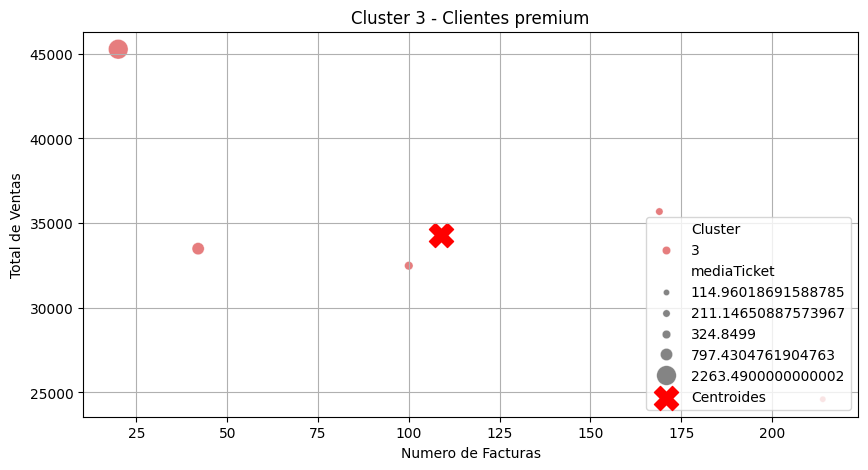

In [86]:
df_to_represent = df_to_use[df_to_use['Cluster'] == 3]
plt.figure(figsize=(10, 5))
sns.scatterplot(
  x='InvoiceNo', 
  y='TotalSales', 
  hue='Cluster',
  size='mediaTicket',
  sizes=(20, 200),
  alpha=0.6,
  palette={ 3: "#d62728" },
  data=df_to_represent
)
plt.scatter(kmeans.cluster_centers_[3, 1], kmeans.cluster_centers_[3, 0], s=300, c='red', marker='X', label='Centroides')
plt.ylabel("Total de Ventas")
plt.xlabel("Numero de Facturas")
plt.title("Cluster 3 - Clientes premium")
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [125]:
df_cluster_3 = df_to_use[df_to_use['Cluster'] == 3]

grouped_cluster_3 = df_cluster_3.groupby('CustomerID').agg({
  "TotalSales": "sum",
  "InvoiceNo": "sum"
})

df_metrics = pd.DataFrame({
  'Metrica': [
    'Número de clientes',
    'Promedio de número de facturas por cliente',
    'Promedio de ventas totales',
    'Número mínimo de facturas',
    'Número máximo de facturas',
    'Ventas totales mínimas',
    'Ventas totales máximas'
  ],
  'Valor': [
    int(grouped_cluster_3.shape[0]),
    round(grouped_cluster_3['InvoiceNo'].mean(), 0).astype(int),
    round(grouped_cluster_3['TotalSales'].mean(), 0).astype(int),
    int(grouped_cluster_3['InvoiceNo'].min()),
    int(grouped_cluster_3['InvoiceNo'].max()),
    int(grouped_cluster_3['TotalSales'].min()),
    int(grouped_cluster_3['TotalSales'].max())
  ]
})

df_metrics

,Metrica,Valor
0,Número de clientes,5
1,Promedio de número de facturas por cliente,109
2,Promedio de ventas totales,34306
3,Número mínimo de facturas,20
4,Número máximo de facturas,214
5,Ventas totales mínimas,24601
6,Ventas totales máximas,45269
